In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import os
import pingouin as pg
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from sqlalchemy import create_engine
from dotenv import load_dotenv

In [33]:
# Global style settings
plt.rcParams.update({
    'figure.figsize': (10, 7),   # Size of all plots
    'axes.grid': True,           # Enable grid
    'grid.alpha': 0.3,           # Grid transparency
    'grid.linestyle': '--',      # Grid style
    'font.size': 12,             # Base font size
    'axes.titlesize': 16,        # Title size
    'axes.labelsize': 14,        # Axis labels
})
plt.style.use('dark_background')

In [72]:
# Load credentials from .env
load_dotenv()
PG_URI = os.getenv("DATABASE_URL")

if not PG_URI:
    raise ValueError("DATABASE_URL not found. Check your .env file.")

# Initialize engine
engine = create_engine(PG_URI)

def get_donations():
    query = """
    SELECT
        d.id, d.date, d.foundation_name, d.category,
        ROUND((d.amount / NULLIF(er.rate_uah, 0))::numeric, 2) AS amount_eur,
        er.rate_uah AS eur_exchange_rate,
        d.currency AS original_currency,
        d.comment, d.source AS donation_source
    FROM donations d    
    LEFT JOIN exchange_rates er ON d.date = er.date AND er.currency = 'EUR'
    WHERE d.date >= '2025-01-01'
    ORDER BY d.date DESC;
    """
    return pd.read_sql(query, engine, parse_dates=['date'])

def get_news():
    query = """
    SELECT
        date,
        STRING_AGG(source, ' | ') AS daily_sources,
        STRING_AGG(headers, ' | ') AS daily_headers
    FROM news
    GROUP BY date
    ORDER BY date DESC;
    """
    return pd.read_sql(query, engine, parse_dates=['date'])

# Execution
df_donations = get_donations()
df_news = get_news()

# Global formatting settings
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_colwidth = 80

print(f"Extraction successful. Donations: {len(df_donations)} | News: {len(df_news)}")

Extraction successful. Donations: 2061569 | News: 441


In [76]:
df = df_donations.copy()
df.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
0,9675899,2026-04-07,come_back_alive,general,2.98,50.32,UAH,UKR ***6347 (150 UAH),Card payment
1,9675900,2026-04-07,come_back_alive,general,5.96,50.32,UAH,UKR ***8664 (300 UAH),Card payment
2,9675901,2026-04-07,come_back_alive,general,4.97,50.32,UAH,ARE ***3238 (250 UAH),Card payment
3,9675902,2026-04-07,come_back_alive,general,4.34,50.32,USD,USA ***1579 (5 USD),Card payment
4,9675903,2026-04-07,come_back_alive,general,1.49,50.32,UAH,UKR ***1723 (75 UAH),Card payment


In [78]:
news = df_news.copy()
news.head()

,date,daily_sources,daily_headers
0,2026-04-07,theguardian.com,"[""Ukraine war briefing: Zelenskyy reiterates truce offer ahead of Orthodox E..."
1,2026-04-06,theguardian.com,['Ukraine war briefing: Russian oil facilities burn as Zelenskyy tours Middl...
2,2026-04-05,theguardian.com,['Ukraine war briefing: Slovakia PM calls on EU to lift sanctions on Russian...
3,2026-04-04,theguardian.com,['‘The frontline is like Terminator’: fighting robots give Ukraine hope in w...
4,2026-04-03,theguardian.com,['Ukraine war briefing: Zelenskyy offers expertise on keeping waterways open...


Here I’ll again work only with CBA Foundation data, because United24 gives only aggregated daily numbers and we can’t split them into proper segments.This time I’m going to look at business donations. I’m assuming that grassroots donors rarely send 10k euros or more, so I’m filtering the table to only CBA and donations from €10,000 upwards.

In [79]:
df = df.query('foundation_name == "come_back_alive" & amount_eur > 10000').copy()

Let's check weekly dynamics

In [80]:
df['week_start']  = df['date'].dt.to_period('W').dt.start_time

In [84]:
whales = df.groupby(['week_start', 'original_currency'], as_index = False)\
            .agg(amount = ('amount_eur', 'sum'))\
            .sort_values('week_start')\
            
whales.head()

,week_start,original_currency,amount
0,2024-12-30,UAH,"423,222.31"
1,2024-12-30,USD,"19,383.61"
2,2025-01-06,UAH,"1,015,911.53"
3,2025-01-13,UAH,"141,767.25"
4,2025-01-13,USD,"135,935.37"


Perfect, now we have a nice clean dataframe segmented by currency to work with

<Axes: xlabel='week_start', ylabel='amount'>

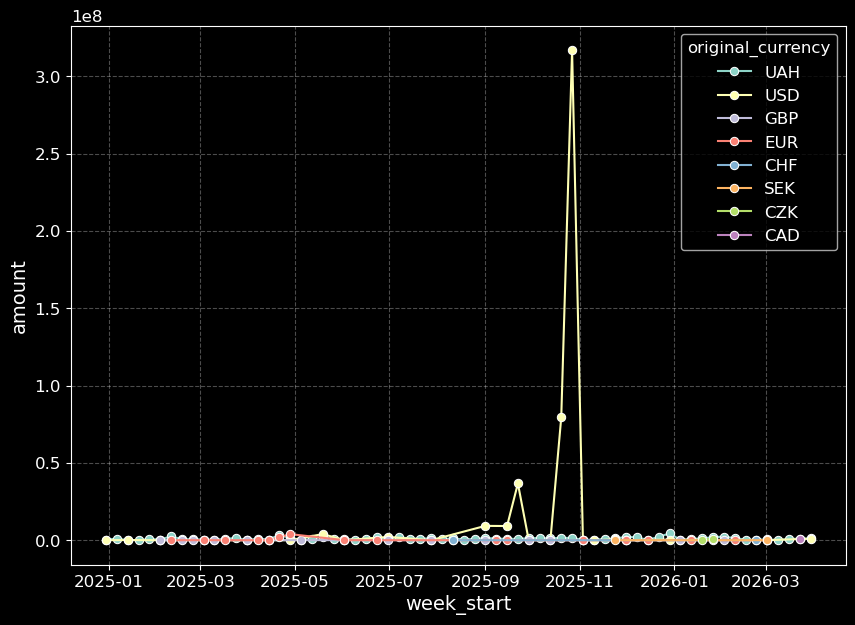

In [91]:
sns.lineplot(whales, x = 'week_start', y = 'amount', hue = 'original_currency', marker='o' )
#plt.legend()


Wow, that November–December peak is enormous! It completely dwarfs everything else and turns the rest of the donations into background noise.  Time to dig deeper into this period.

In [92]:
peak = whales[(whales.week_start > '2025-09-20') & (whales.week_start < '2025-11-10')].reset_index(drop = True)

<Axes: xlabel='week_start', ylabel='amount'>

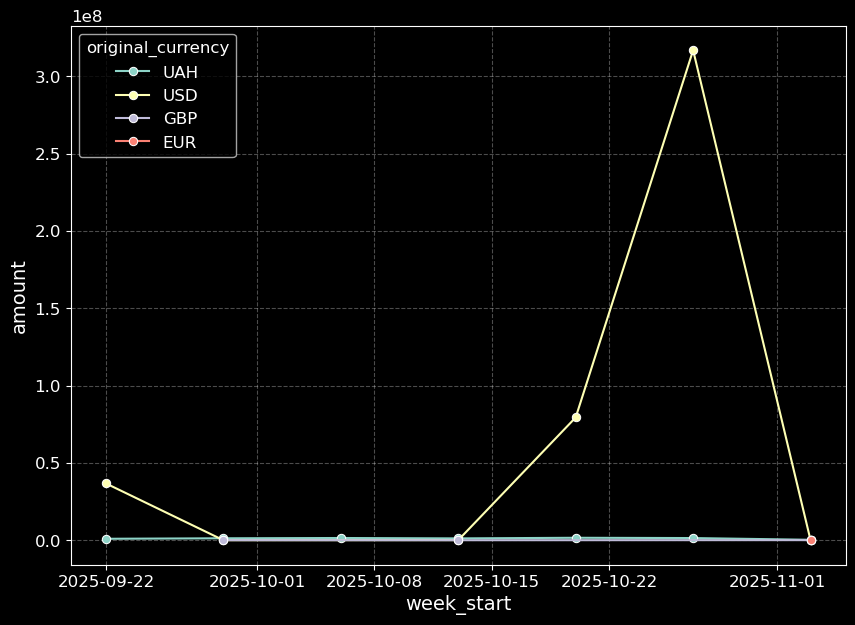

In [93]:
sns.lineplot(peak, x = 'week_start', y = 'amount', hue = 'original_currency', marker='o')

Let's look even closer

In [94]:
peak = whales[(whales.week_start > '2025-10-08') & (whales.week_start < '2025-11-15')].reset_index(drop = True)

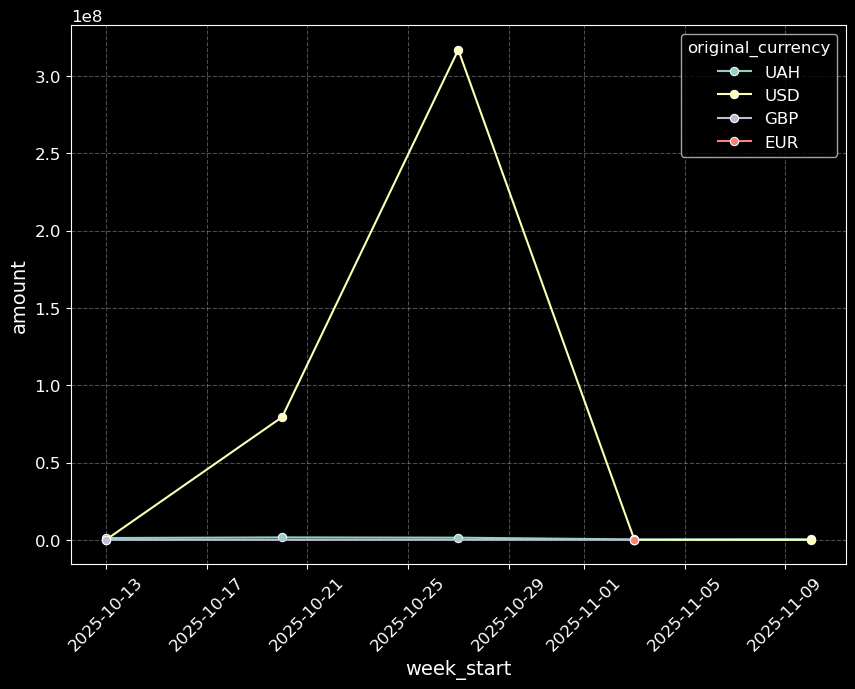

In [96]:
sns.lineplot(peak, x = 'week_start', y = 'amount' , hue = 'original_currency', marker='o')
plt.xticks(rotation = 45)
plt.show()

In [97]:
start, end = '2025-10-13', '2025-10-29'

In [104]:
peak_news = news[news.date.between(start, end)].reset_index()
print(f'Found {len(peak_news)}')
peak_news.head()

Found 17


,index,date,daily_sources,daily_headers
0,158,2025-10-29,kyivindependent.com | theguardian.com,"[""Gripen jets are coming to Ukraine — here's how they can be used against Ru..."
1,159,2025-10-28,kyivindependent.com | theguardian.com,"['Russian troops outnumber Ukraine 8-1 in Pokrovsk sector, Zelensky says', '..."
2,160,2025-10-27,kyivindependent.com | theguardian.com,"[""Ukraine war latest updates: HUR 'liquidates' son of Russian general, relea..."
3,161,2025-10-26,theguardian.com,['Trump sanctions have swift impact but will world stop buying Russian oil a...
4,162,2025-10-25,kyivindependent.com | theguardian.com,"[""Ukrainian drones strike electrical substation in Russia's Volgograd Oblast..."


In [68]:
for i in peak_news.news:
    print(i)

['Ukraine war briefing: Putin back in Trump’s ear as soon as Tomahawks came up, says Zelenskyy', 'Trump hesitant about giving Tomahawks to Ukraine, saying ‘hopefully they won’t need it’ – as it happened', 'Donald Trump claims to be the president of peace, but at home he is fomenting civil war | Jonathan Freedland', 'Trump claims Maduro willing to give ‘everything’ to ease US tensions', 'Trump downplays hopes he will supply Ukraine with US missiles after meeting with Zelenskyy', 'Trump news at a glance: John Bolton vows to defend his conduct after indictment']
['Ukraine war briefing: Lithuania accuses Russia of further Nato airspace violation', 'Ukraine wants US to stay involved, says Zelenskyy after meeting western allies', 'Six Britons acting for Wagner group jailed for arson attack on UK warehouse', '‘Sacred sanctuary’: North Korea starts building memorial to soldiers killed in Ukraine war']
['Ukraine war briefing: British ex-soldier arrested in Kyiv and accused of spying for Russia'

The same old story: Trump refuses to help Ukraine, Trump listens to Putin, and so on. I doubt that this is what caused such a spike (since this has been ongoing throughout Trump’s term). Let’s take a closer look at where exactly all this money came from.

In [112]:
dates = peak_news.date

In [117]:
# cutting df to explore closer rush dates
peak_df = df[df.date.isin(dates)].reset_index()
peak_df.head()

,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
0,586491,7808555,2025-10-29,come_back_alive,general,"79,048,013.00",48.98,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
1,587592,7807514,2025-10-29,come_back_alive,general,"20,417.16",48.98,UAH,"ТОВ ""МІТ УКРАЇНА"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27
2,587593,7807515,2025-10-29,come_back_alive,general,"17,251.24",48.98,UAH,"ТОВ ""АСФ ТРЕЙД"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27
3,587595,7807517,2025-10-29,come_back_alive,general,"22,560.97",48.98,UAH,"ТОВ ""РУХ ФІНАНС"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27
4,587596,7807518,2025-10-29,come_back_alive,general,"30,625.75",48.98,UAH,"ТОВ ""МАКРО ГРОССЕРІ"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27


In [123]:
# Top 6 donations in this period
top6 = peak_df.sort_values('amount_eur', ascending = False).reset_index().head(6)
top6

,level_0,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
0,40,609622,7785246,2025-10-23,come_back_alive,general,"79,419,876.37",48.37,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-20
1,25,592783,7802323,2025-10-27,come_back_alive,general,"79,228,384.88",48.77,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
2,0,586491,7808555,2025-10-29,come_back_alive,general,"79,048,013.00",48.98,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
3,13,589879,7805220,2025-10-28,come_back_alive,general,"79,030,934.66",48.97,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
4,27,594213,7800819,2025-10-27,come_back_alive,general,"410,115.08",48.77,UAH,"АТ ""КОНЦЕРН ГАЛНАФТОГАЗ"" -- Благодійна пожертва",Oschad,2025-10-27
5,49,609681,7785037,2025-10-23,come_back_alive,general,"243,594.02",48.37,UAH,"Акціонерне товариство ""Укрнафта -- Безповоротна фінансова благодійна допомога",Oschad,2025-10-20


Yes, we identified the source of the “mysterious” spike — transfers labeled “To support Ukrainian Defence according to the Grant Agreement” from the USA. Most likely, this reflects one of the final funding tranches from the Biden administration. Let's see how many they transfered during the whole period from 2025-01-01

In [127]:
# Finding thw US help
usa = df[df.comment == 'To support Ukrainian Defence according to the Grant Agreement']
usa

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
579094,7821966,2025-10-31,come_back_alive,general,"79,591,723.49",48.51,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
586491,7808555,2025-10-29,come_back_alive,general,"79,048,013.00",48.98,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
589879,7805220,2025-10-28,come_back_alive,general,"79,030,934.66",48.97,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
592783,7802323,2025-10-27,come_back_alive,general,"79,228,384.88",48.77,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
609622,7785246,2025-10-23,come_back_alive,general,"79,419,876.37",48.37,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-20
828965,6171111,2025-09-05,come_back_alive,general,"9,277,560.52",48.13,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-09-01


In [129]:
# Total USA help to Come Back Alive
usa.amount_eur.sum()

405596492.91999996

400+ million is impressive. Let’s exclude that from our analysis and focus on business support rather than the USA.

In [140]:
# Deleting USA huge donations
df_clean = df.drop(usa.index)
df_clean_week = df_clean.groupby('week_start', as_index = False).agg({'amount_eur':'sum'})

<Axes: xlabel='week_start', ylabel='amount_eur'>

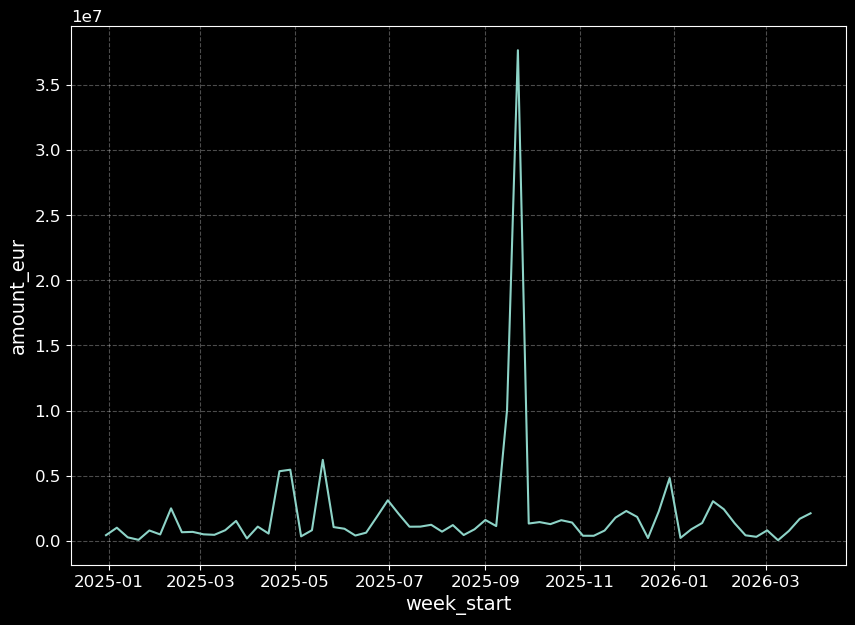

In [141]:
sns.lineplot(df_clean_week, x = 'week_start', y = 'amount_eur')

Another huge peak almost the same period!

In [143]:
peak_df = df_clean[df_clean['date'].between('2025-09-10', '2025-10-10')]

In [146]:
peak_df.sort_values('amount_eur', ascending = False).head(7)

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
771988,6701450,2025-09-22,come_back_alive,general,"9,200,503.08",48.42,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
768805,6705040,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
769068,6705039,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
768806,6705041,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
780652,6540409,2025-09-19,come_back_alive,general,"9,131,639.64",48.78,USD,For the needs of Ukrainian Defence,Universal,2025-09-15
743825,6781147,2025-10-01,come_back_alive,general,"517,568.34",48.30,UAH,"ТОВ ""ОККО-ДРАЙВ"" -- Благодійна пожертва",Oschad,2025-09-29
813748,6180446,2025-09-10,come_back_alive,general,"268,632.64",48.29,UAH,Акцiонерне товариство 'Укрнафта' -- Безповоротна фiнансова благодiйна допомога,Oschad,2025-09-08


Yep, we found more USA transhes "For the needs of Ukrainian Defence", let's see are there more of them

In [147]:
df_clean[df_clean.comment  == 'For the needs of Ukrainian Defence']

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
327342,9320695,2025-12-29,come_back_alive,general,"372,192.81",49.56,USD,For the needs of Ukrainian Defence,Tascombank,2025-12-29
768805,6705040,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
768806,6705041,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
769068,6705039,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
771988,6701450,2025-09-22,come_back_alive,general,"9,200,503.08",48.42,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
780652,6540409,2025-09-19,come_back_alive,general,"9,131,639.64",48.78,USD,For the needs of Ukrainian Defence,Universal,2025-09-15


No, there aren’t. Let’s exclude them as well, but keep the one that clearly stands out.

In [148]:
usa_aid = df_clean[df_clean.comment  == 'For the needs of Ukrainian Defence'][1:]

In [150]:
df_clean = df_clean.drop(usa_aid.index)

<Axes: xlabel='week_start', ylabel='amount_eur'>

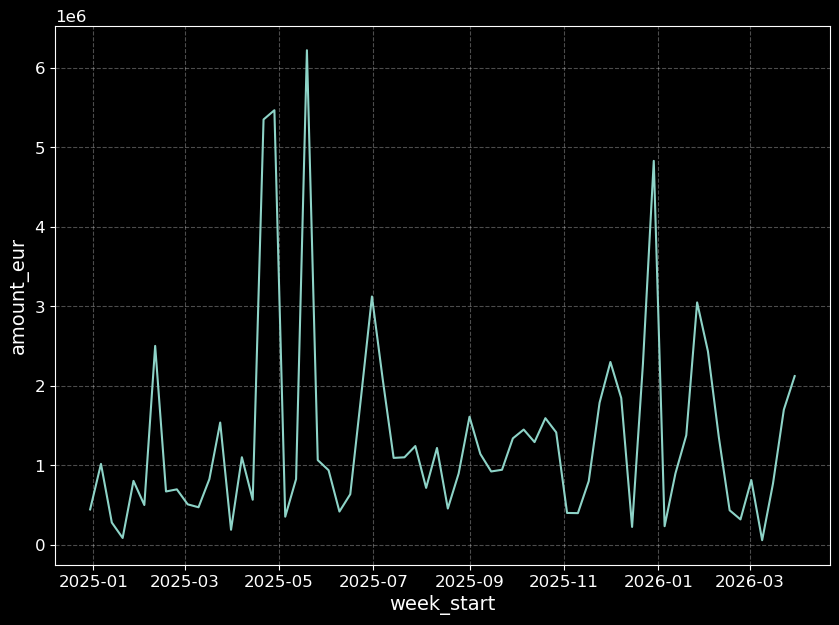

In [153]:
df_clean_week = df_clean.groupby('week_start', as_index = False).agg({'amount_eur':'sum'})
sns.lineplot(df_clean_week, x = 'week_start', y = 'amount_eur')